<h1><font color='blue'>Análise de Sentimentos e Sistemas de Recomendação</font></h1>
<h2><b>Prática U1-T2-V4.2-Abordagens baseadas em deep learning</b></h2>


---

## Preparação

### Carregando o dataset

In [1]:
import pandas as pd
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1M7VtNfEh7K3gqa4OiWiayPkg8q6x8fXk', encoding='utf-8', low_memory=False)
df.head()

,frase_pt,frase_en,sentimento
0,O atendimento ao cliente foi excepcional e res...,The customer service was exceptional and solve...,Positivo
1,"Este é, sem dúvida, o melhor café que já prove...","This is, without a doubt, the best coffee I've...",Positivo
2,O filme tem uma fotografia incrível e uma tril...,The movie has incredible cinematography and a ...,Positivo
3,Estou muito satisfeito com a qualidade do prod...,I am very satisfied with the product's quality...,Positivo
4,A equipe foi extremamente simpática e prestati...,The staff was extremely friendly and helpful t...,Positivo


In [2]:
df['sentimento'].value_counts()

,count
sentimento,
Positivo,10
Negativo,10
Neutro,10


## Abordagem baseada em *Machine Learning* usando *Embeddings*

Usar a abordagem baseada em *machine learning* com a representação do texto usando *embeddings*.

In [3]:
X = df['frase_pt'].values.tolist()
y = df['sentimento'].values.tolist()

X[:10]

['O atendimento ao cliente foi excepcional e resolveu meu problema rapidamente.',
 'Este é, sem dúvida, o melhor café que já provei na cidade!',
 'O filme tem uma fotografia incrível e uma trilha sonora emocionante.',
 'Estou muito satisfeito com a qualidade do produto, superou minhas expectativas.',
 'A equipe foi extremamente simpática e prestativa durante toda a minha visita.',
 'Que experiência maravilhosa! Com certeza voltarei mais vezes.',
 'O livro chegou em perfeito estado e antes do prazo. Recomendo!',
 'A vista do quarto do hotel é absolutamente deslumbrante.',
 'Adorei a nova funcionalidade do aplicativo, ficou muito mais fácil de usar.',
 'O show foi espetacular, uma energia contagiante do início ao fim.']

In [4]:
y[:10]

['Positivo',
 'Positivo',
 'Positivo',
 'Positivo',
 'Positivo',
 'Positivo',
 'Positivo',
 'Positivo',
 'Positivo',
 'Positivo']

### Separar as frases para treino (80%) e teste (20%)

Vamos utilizar 80% das frases de exemplo, para as quais já se conhece o sentimento, para treinar o modelo classificador baseado em *machine learning*.

Os 20% dos dados restantes serão utilizados para avaliar o desempenho do modelo treinado.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train[:10]

['A entrega foi feita no endereço combinado, conforme o pedido.',
 'A cor do carro é cinza e ele tem quatro portas.',
 'A comida estava fria e o garçom demorou uma eternidade para nos atender.',
 'O atendimento ao cliente foi excepcional e resolveu meu problema rapidamente.',
 'A equipe foi extremamente simpática e prestativa durante toda a minha visita.',
 'Péssima experiência de compra, o site é confuso e o suporte não ajuda.',
 'Que experiência maravilhosa! Com certeza voltarei mais vezes.',
 'Que filme terrível, o roteiro é fraco e as atuações são péssimas.',
 'Estou profundamente decepcionado com o serviço prestado, não recomendo.',
 'O voo de Belo Horizonte para São Paulo tem duração de aproximadamente uma hora.']

### Convertendo as frases para a representação vetorial (*Embeddings*) que considera o significado do texto.

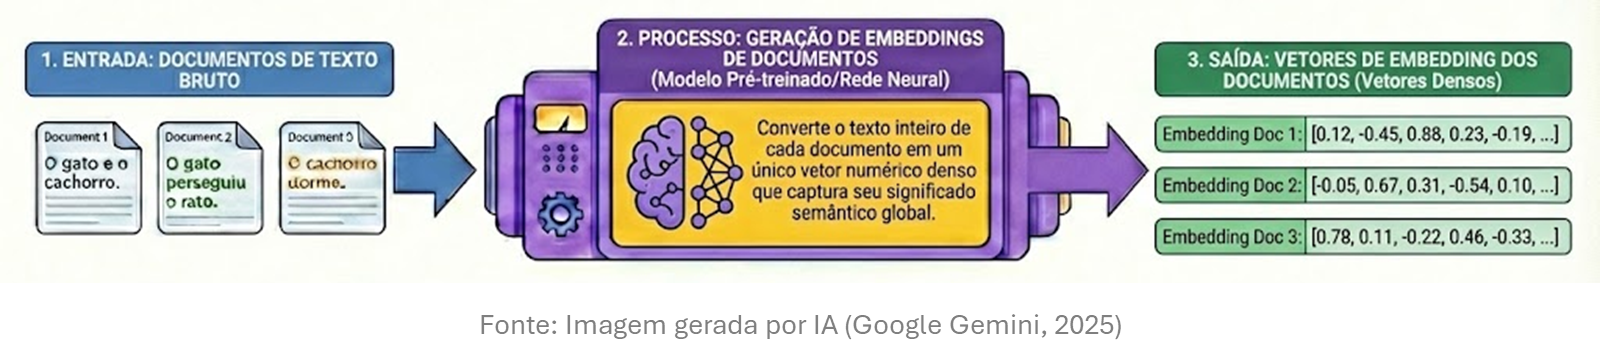

In [6]:
!pip install -q sentence-transformers

In [7]:
from sentence_transformers import SentenceTransformer

model_name = "all-MiniLM-L6-v2"
embedder = SentenceTransformer(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
X_train_vetor = embedder.encode(X_train)
X_test_vetor = embedder.encode(X_test)
X_train_vetor[0]

array([ 1.40748592e-02,  4.56191935e-02, -8.96977931e-02, -3.65881063e-02,
       -8.68910402e-02, -4.38461266e-02,  3.14428732e-02,  6.19691908e-02,
       -5.02163963e-03,  8.22350979e-02,  9.04401243e-02, -4.20265459e-02,
       -8.49941820e-02,  4.81457114e-02, -1.52789308e-02, -1.51855461e-02,
       -5.77229969e-02,  3.12576964e-02, -1.66523978e-02,  1.12335786e-01,
        6.88407943e-02, -3.64327356e-02, -6.30469918e-02,  6.95948303e-02,
       -1.16916403e-01,  8.26964155e-02, -4.15672846e-02,  1.90229677e-02,
       -4.32939380e-02, -2.43763849e-02,  1.73276234e-02,  1.04040995e-01,
        1.06727153e-01, -4.52339128e-02,  1.69386696e-02, -1.32939778e-02,
        1.59414485e-02, -1.58103034e-02,  4.20943610e-02,  2.48530135e-02,
       -8.41808245e-02, -9.33910161e-03, -3.98101173e-02, -2.27392819e-02,
        4.93480265e-03, -5.68813179e-03,  1.99693721e-02,  5.84392399e-02,
        6.84024245e-02,  1.23117464e-02, -4.60537001e-02,  1.70296431e-02,
       -7.75587410e-02,  

### Treinar o modelo classificador

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_vetor, y_train)


LogisticRegression(max_iter=1000, random_state=42)

### Testar o modelo em novos dados

Converter o texto para a representação vetorial numérica

In [10]:
X_new = embedder.encode(['O atendimento ao cliente foi excepcional e resolveu meu problema rapidamente.'])
X_new

array([[ 1.43711653e-03,  7.62373805e-02, -4.49168384e-02,
        -3.19137052e-02, -9.95213240e-02, -1.13434521e-02,
         3.96301635e-02,  1.21706814e-01,  2.17641164e-02,
         5.41939139e-02,  4.90818471e-02, -5.45291696e-03,
         8.67214403e-04,  9.23769269e-03,  5.38454726e-02,
        -6.64362758e-02, -2.72926688e-03,  1.03813652e-02,
        -1.77211093e-03,  3.85507680e-02,  2.06329823e-02,
        -5.50367609e-02, -1.09633453e-01,  1.09893968e-02,
        -1.27439320e-01, -1.40274800e-02,  3.90589014e-02,
        -3.02253067e-02,  3.23068313e-02, -2.37891376e-02,
         2.94146705e-02,  1.21648431e-01,  6.15396984e-02,
        -4.87845279e-02, -3.93636748e-02,  5.83711676e-02,
         2.98028532e-03, -4.53858152e-02, -1.85554102e-02,
        -4.90788464e-03, -2.20250320e-02, -5.46381287e-02,
        -6.69670403e-02, -8.62037912e-02,  6.50185645e-02,
        -3.24091911e-02,  5.19498810e-02,  8.27052519e-02,
         2.18626414e-03, -2.23363079e-02, -1.63551450e-0

In [11]:
model.predict(X_new)

array(['Positivo'], dtype='<U8')

### Avaliar modelo no conjunto de testes

In [12]:
y_pred = model.predict(X_test_vetor)
y_pred.tolist()

['Neutro', 'Neutro', 'Positivo', 'Negativo', 'Positivo', 'Negativo']

In [13]:
y_test

['Neutro', 'Negativo', 'Neutro', 'Negativo', 'Positivo', 'Positivo']

In [14]:
for frase, sentimento, predito in zip(X_test, y_test, y_pred):
    print(f'Frase: {frase:<80} - Sentimento: pred "{predito}" - real "{sentimento}"')


Frase: A bateria do celular dura o dia todo com uso moderado.                           - Sentimento: pred "Neutro" - real "Neutro"
Frase: Não gostei do final da série, achei que estragou toda a história.                - Sentimento: pred "Neutro" - real "Negativo"
Frase: Este documento contém as especificações técnicas do produto.                     - Sentimento: pred "Positivo" - real "Neutro"
Frase: O trânsito hoje estava simplesmente insuportável.                                - Sentimento: pred "Negativo" - real "Negativo"
Frase: Adorei a nova funcionalidade do aplicativo, ficou muito mais fácil de usar.      - Sentimento: pred "Positivo" - real "Positivo"
Frase: O show foi espetacular, uma energia contagiante do início ao fim.                - Sentimento: pred "Negativo" - real "Positivo"


Ver a taxa de acerto (acurácia)

In [15]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.5

## Abordagem baseada em Deep Learning (Transformers)

As abordagens de deep learning representam uma mudança fundamental na forma como processamos texto para análise de sentimentos.

Diferentemente do machine learning tradicional, que requer engenharia manual de features e trata texto como dados estáticos, o deep learning aprende automaticamente representações hierárquicas e contextuais do texto através de redes neurais profundas.



### Frases em inglês

In [16]:
!pip install -q transformers

In [17]:
from transformers import pipeline

#sa = pipeline("sentiment-analysis")
sa = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment-latest")


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [18]:
retorno = sa("I like this product")
retorno

[{'label': 'positive', 'score': 0.9538777470588684}]

In [19]:
def retorna_sentimento(retorno):
    if retorno['label'] == 'negative':
        return 'Negativo'
    elif retorno['label'] == 'neutral':
        return 'Neutro'
    elif retorno['label'] == 'positive':
        return 'Positivo'

retorna_sentimento(retorno[0])

'Positivo'

In [20]:
y_pred = []
for frase, sentimento in df[['frase_en','sentimento']].values.tolist():
    res = sa(frase)
    retorno = retorna_sentimento(res[0])
    y_pred.append(retorno)
    print(f'Frase: {frase:<90} - Sentimento: pred "{retorno}" - real "{sentimento}" \n\t{res[0]}')


Frase: The customer service was exceptional and solved my problem quickly.                        - Sentimento: pred "Positivo" - real "Positivo" 
	{'label': 'positive', 'score': 0.9297541975975037}
Frase: This is, without a doubt, the best coffee I've ever tasted in the city!                    - Sentimento: pred "Positivo" - real "Positivo" 
	{'label': 'positive', 'score': 0.9859880805015564}
Frase: The movie has incredible cinematography and a moving soundtrack.                           - Sentimento: pred "Positivo" - real "Positivo" 
	{'label': 'positive', 'score': 0.983791708946228}
Frase: I am very satisfied with the product's quality, it exceeded my expectations.               - Sentimento: pred "Positivo" - real "Positivo" 
	{'label': 'positive', 'score': 0.9851306080818176}
Frase: The staff was extremely friendly and helpful throughout my entire visit.                   - Sentimento: pred "Positivo" - real "Positivo" 
	{'label': 'positive', 'score': 0.9793727993965149}
Frase:

Ver a taxa de acerto (acurácia)

In [21]:
from sklearn.metrics import accuracy_score

y_test = df['sentimento'].values.tolist()
accuracy_score(y_test, y_pred)

0.9333333333333333

### Frases em português

In [22]:
sa = pipeline("sentiment-analysis",model="lucas-leme/FinBERT-PT-BR")


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: lucas-leme/FinBERT-PT-BR
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/559 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [23]:
retorno = sa("Eu adorei este produto")
retorno

[{'label': 'POSITIVE', 'score': 0.5155050754547119}]

In [24]:
def retorna_sentimento(retorno):
    if retorno['label'] == 'NEGATIVE':
        return 'Negativo'
    elif retorno['label'] == 'NEUTRAL':
        return 'Neutro'
    elif retorno['label'] == 'POSITIVE':
        return 'Positivo'

retorna_sentimento(retorno[0])

'Positivo'

In [25]:
y_pred = []
for frase, sentimento in df[['frase_pt','sentimento']].values.tolist():
    res = sa(frase)
    retorno = retorna_sentimento(res[0])
    y_pred.append(retorno)
    print(f'Frase: {frase:<90} - Sentimento: pred "{retorno}" - real "{sentimento}" \n\t{res[0]}')


Frase: O atendimento ao cliente foi excepcional e resolveu meu problema rapidamente.              - Sentimento: pred "Positivo" - real "Positivo" 
	{'label': 'POSITIVE', 'score': 0.6414068937301636}
Frase: Este é, sem dúvida, o melhor café que já provei na cidade!                                 - Sentimento: pred "Positivo" - real "Positivo" 
	{'label': 'POSITIVE', 'score': 0.7515318989753723}
Frase: O filme tem uma fotografia incrível e uma trilha sonora emocionante.                       - Sentimento: pred "Positivo" - real "Positivo" 
	{'label': 'POSITIVE', 'score': 0.6125232577323914}
Frase: Estou muito satisfeito com a qualidade do produto, superou minhas expectativas.            - Sentimento: pred "Positivo" - real "Positivo" 
	{'label': 'POSITIVE', 'score': 0.8268324732780457}
Frase: A equipe foi extremamente simpática e prestativa durante toda a minha visita.              - Sentimento: pred "Positivo" - real "Positivo" 
	{'label': 'POSITIVE', 'score': 0.7414060831069946}
Frase

In [26]:
from sklearn.metrics import accuracy_score

y_test = df['sentimento'].values.tolist()
accuracy_score(y_test, y_pred)

0.8666666666666667

## Abordagem de estrelas (de 1 a 5 estrelas)

In [27]:
from transformers import pipeline

# Modelo treinado para português (e.g., BERTimbau)
analisador = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")




config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [28]:
# Avaliação de 1 a 5 estrelas
print(analisador("Esse restaurante é incrível!"))

[{'label': '5 stars', 'score': 0.79572594165802}]


In [29]:
print(analisador("Detestei. Péssimo!"))

[{'label': '1 star', 'score': 0.9457364678382874}]


In [30]:
print(analisador("Nunca mais volto aqui!"))

[{'label': '5 stars', 'score': 0.5334627032279968}]


In [31]:
print(analisador("Não volto aqui!"))

[{'label': '1 star', 'score': 0.7677045464515686}]


## Análise de emoções com Pysentimiento

🔹 O que é o pysentimiento?
O **pysentimiento** é uma biblioteca Python para **análise de sentimentos, emoções e discurso de ódio**, baseada em **modelos Transformer (BERT)**.  
Ela foi desenvolvida para ser **simples de usar**, **precisa** e **multilíngue**, com ótimo suporte ao **português**.

🔹 Principais funcionalidades
- Análise de **sentimentos** (positivo, negativo, neutro)
- Detecção de **emoções** (alegria, raiva, tristeza, medo, etc.)
- Detecção de **hate speech**
- Modelos pré-treinados para:
  - Português
  - Espanhol
  - Inglês


In [32]:
!pip install -q pysentimiento

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 11.5 MB/s eta 0:00:00


In [33]:
from pysentimiento import create_analyzer

# Criando o analisador de emoções
emocao_analyzer = create_analyzer(task="emotion", lang="pt")


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/367 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/61.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [34]:
emocao_analyzer.predict("Estou em estado de graça. Tudo estava ótimo.")

AnalyzerOutput(output=['admiration'], probas={admiration: 0.973, amusement: 0.001, anger: 0.000, annoyance: 0.001, approval: 0.061, caring: 0.002, confusion: 0.000, curiosity: 0.001, desire: 0.001, disappointment: 0.001, disapproval: 0.000, disgust: 0.000, embarrassment: 0.000, excitement: 0.009, fear: 0.000, gratitude: 0.014, grief: 0.000, joy: 0.015, love: 0.002, nervousness: 0.000, optimism: 0.004, pride: 0.004, realization: 0.002, relief: 0.001, remorse: 0.000, sadness: 0.001, surprise: 0.001, neutral: 0.006})

In [35]:
emocao_analyzer.predict("Péssimo! Que raiva. Estou muito desapontado com o serviço.")


AnalyzerOutput(output=['disappointment'], probas={admiration: 0.007, amusement: 0.002, anger: 0.275, annoyance: 0.301, approval: 0.003, caring: 0.002, confusion: 0.005, curiosity: 0.004, desire: 0.004, disappointment: 0.633, disapproval: 0.018, disgust: 0.083, embarrassment: 0.036, excitement: 0.004, fear: 0.012, gratitude: 0.005, grief: 0.007, joy: 0.003, love: 0.003, nervousness: 0.020, optimism: 0.004, pride: 0.004, realization: 0.005, relief: 0.002, remorse: 0.006, sadness: 0.169, surprise: 0.008, neutral: 0.002})